# Phase 5: Executive Summary & Final Pricing Strategy

## Overview
This notebook synthesizes all Phase 4 elasticity analysis outputs into a comprehensive, stakeholder-ready pricing strategy.

### Objectives
1. **Load & integrate** all Phase 4 outputs (elasticity, optimal prices, guardrailed recommendations)
2. **Compile comprehensive recommendations table** with all key metrics for each store
3. **Generate executive insights** (segment breakdown, aggregate uplift, risk assessment)
4. **Create stakeholder visualizations** (recommendation heatmap, segment distribution, revenue impact)
5. **Export final deliverables** in multiple formats (CSV for action, JSON for API)

### Key Metrics Included
- **Store ID & Location**: Store reference
- **Elasticity Segment**: High/Medium/Low sensitivity classification
- **Price Elasticity**: Actual demand elasticity (quantity change per 1% price change)
- **Current Price & Baseline Revenue**: Baseline scenario
- **Recommended Multiplier & Price**: Guardrailed price adjustment
- **Expected Demand & Revenue Change**: Projected impact in % and absolute values
- **Decision Type**: Reason for recommendation (GuardrailedOptimum, Baseline, etc.)
- **Implementation Risk**: Segment-appropriate risk level

## Cell 1: Load All Phase 4 Outputs

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Change to project root
os.chdir('..')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load Phase 4 outputs
print('Loading Phase 4 outputs...')
recommended = pd.read_csv('output/phase4_recommended_prices_guardrailed.csv')
elasticity = pd.read_csv('output/phase4_store_elasticity.csv')
simulations = pd.read_csv('output/phase4_price_simulation_results.csv')
optimal = pd.read_csv('output/phase4_optimal_prices_by_store.csv')

print(f'Recommended prices shape: {recommended.shape}')
print(f'Store elasticity shape: {elasticity.shape}')
print(f'Price simulations shape: {simulations.shape}')
print(f'Optimal prices shape: {optimal.shape}')
print('\nFirst few rows of recommendations:')
print(recommended.head())

Loading Phase 4 outputs...
Recommended prices shape: (45, 12)
Store elasticity shape: (45, 3)
Price simulations shape: (945, 7)
Optimal prices shape: (45, 7)

First few rows of recommendations:
   Store        Date  Elasticity Elasticity_Segment  Base_Price  \
0      1  2012-10-26   -0.034598     LowSensitivity       84.11   
1      2  2012-10-26   -0.043807     LowSensitivity       86.40   
2      3  2012-10-26   -0.124032    HighSensitivity       83.14   
3      4  2012-10-26   -0.021182     LowSensitivity       81.32   
4      5  2012-10-26   -0.189900    HighSensitivity       78.45   

   Recommended_Price  Recommended_Multiplier  Recommended_Demand  \
0            95.8854                    1.14        1.549488e+06   
1            98.4960                    1.14        1.858219e+06   
2            86.4656                    1.04        4.202336e+05   
3            92.7048                    1.14        2.215043e+06   
4            81.5880                    1.04        3.315977e+0

## Cell 2: Load Baseline Data (Current Prices & Demand)

In [17]:
# Extract baseline metrics from Phase 4 simulation data (multiplier = 1.0 is baseline)
print('Extracting baseline metrics from Phase 4 simulations...')

# Get baseline scenario (multiplier = 1.0) for each store
baseline_scenario = simulations[simulations['Price_Multiplier'] == 1.0].copy()
baseline_scenario = baseline_scenario.groupby('Store', as_index=False).first()[['Store', 'Base_Sim_Price', 'Simulated_Price', 'Predicted_Demand', 'Predicted_Revenue']]
baseline_scenario.rename(columns={
    'Base_Sim_Price': 'Current_Price',
    'Predicted_Demand': 'Baseline_Demand',
    'Predicted_Revenue': 'Baseline_Revenue',
    'Simulated_Price': 'Baseline_Price'
}, inplace=True)

print(f'Baseline data shape: {baseline_scenario.shape}')
print(baseline_scenario.head(10))

Extracting baseline metrics from Phase 4 simulations...
Baseline data shape: (45, 5)
   Store  Current_Price  Baseline_Price  Baseline_Demand  Baseline_Revenue
0      1          84.11           84.11     1.551172e+06      1.304691e+08
1      2          86.40           86.40     1.858219e+06      1.605501e+08
2      3          83.14           83.14     4.202336e+05      3.493822e+07
3      4          81.32           81.32     2.215052e+06      1.801280e+08
4      5          78.45           78.45     3.315977e+05      2.601384e+07
5      6          87.67           87.67     1.484217e+06      1.301213e+08
6      7          92.63           92.63     5.329782e+05      4.936977e+07
7      8          83.29           83.29     9.116107e+05      7.592805e+07
8      9          83.83           83.83     5.641410e+05      4.729194e+07
9     10          87.30           87.30     1.786697e+06      1.559786e+08


## Cell 3: Build Comprehensive Executive Recommendations Table

In [18]:
# Merge all data sources
print('Building comprehensive recommendations table...')

# Since recommended has one row per store-date, get first date per store
executive_recs = recommended.groupby('Store', as_index=False).first()

# Merge baseline data
executive_recs = executive_recs.merge(baseline_scenario, on='Store', how='left')

# Reorder and select necessary columns for executive clarity
executive_recs = executive_recs[[
    'Store',
    'Elasticity_Segment',
    'Elasticity',
    'Current_Price',
    'Baseline_Demand',
    'Baseline_Revenue',
    'Recommended_Multiplier',
    'Recommended_Price',
    'Recommended_Demand',
    'Recommended_Revenue',
    'Expected_Demand_Change_Pct',
    'Expected_Revenue_Change_Pct',
    'Decision_Type'
]].copy()

# Add derived metrics
executive_recs['Price_Change_Pct'] = ((executive_recs['Recommended_Price'] / executive_recs['Current_Price']) - 1) * 100
executive_recs['Expected_Revenue_Change_Abs'] = executive_recs['Recommended_Revenue'] - executive_recs['Baseline_Revenue']

# Set implementation risk level based on elasticity segment
risk_map = {'HighSensitivity': 'LOW', 'MediumSensitivity': 'MEDIUM', 'LowSensitivity': 'HIGH'}
executive_recs['Implementation_Risk'] = executive_recs['Elasticity_Segment'].map(risk_map)

# Sort by store ID
executive_recs = executive_recs.sort_values('Store').reset_index(drop=True)

print(f'Executive recommendations shape: {executive_recs.shape}')
print('\\nFirst 10 stores:')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(executive_recs[['Store', 'Elasticity_Segment', 'Elasticity', 'Current_Price', 
                       'Recommended_Multiplier', 'Price_Change_Pct', 'Expected_Revenue_Change_Pct']].head(10))

Building comprehensive recommendations table...
Executive recommendations shape: (45, 16)
\nFirst 10 stores:
   Store Elasticity_Segment  Elasticity  Current_Price  \
0      1     LowSensitivity   -0.034598          84.11   
1      2     LowSensitivity   -0.043807          86.40   
2      3    HighSensitivity   -0.124032          83.14   
3      4     LowSensitivity   -0.021182          81.32   
4      5    HighSensitivity   -0.189900          78.45   
5      6     LowSensitivity   -0.034635          87.67   
6      7     LowSensitivity   -0.009204          92.63   
7      8    HighSensitivity   -0.105133          83.29   
8      9    HighSensitivity   -0.142498          83.83   
9     10     LowSensitivity   -0.027761          87.30   

   Recommended_Multiplier  Price_Change_Pct  Expected_Revenue_Change_Pct  
0                    1.14              14.0                    13.876246  
1                    1.14              14.0                    14.000000  
2                    1.04  

## Cell 4: Executive Summary Statistics & Insights

In [19]:
# Generate executive summary statistics
print('='*60)
print('EXECUTIVE SUMMARY: PRICING STRATEGY INSIGHTS')
print('='*60)

print('\n1. SEGMENT BREAKDOWN')
segment_counts = executive_recs['Elasticity_Segment'].value_counts()
for segment, count in segment_counts.items():
    pct = 100 * count / len(executive_recs)
    print(f'   {segment}: {count} stores ({pct:.1f}%)')

print('\n2. PRICE ADJUSTMENT DISTRIBUTION')
price_stats = {
    'Min Multiplier': executive_recs['Recommended_Multiplier'].min(),
    'Mean Multiplier': executive_recs['Recommended_Multiplier'].mean(),
    'Max Multiplier': executive_recs['Recommended_Multiplier'].max(),
    'Std Dev': executive_recs['Recommended_Multiplier'].std(),
}
for key, val in price_stats.items():
    print(f'   {key}: {val:.4f}')

print('\n3. EXPECTED REVENUE IMPACT (Portfolio-Wide)')
total_baseline_revenue = executive_recs['Baseline_Revenue'].sum()
total_recommended_revenue = executive_recs['Recommended_Revenue'].sum()
total_uplift_abs = total_recommended_revenue - total_baseline_revenue
total_uplift_pct = (total_uplift_abs / total_baseline_revenue) * 100

print(f'   Total Baseline Revenue: ${total_baseline_revenue:,.0f}')
print(f'   Total Recommended Revenue: ${total_recommended_revenue:,.0f}')
print(f'   Portfolio Uplift: ${total_uplift_abs:,.0f} ({total_uplift_pct:.2f}%)')
print(f'   Avg Store Uplift: {executive_recs["Expected_Revenue_Change_Pct"].mean():.2f}%')
print(f'   Uplift Range: {executive_recs["Expected_Revenue_Change_Pct"].min():.2f}% to {executive_recs["Expected_Revenue_Change_Pct"].max():.2f}%')

print('\n4. ELASTICITY INSIGHTS')
for segment in ['HighSensitivity', 'MediumSensitivity', 'LowSensitivity']:
    seg_data = executive_recs[executive_recs['Elasticity_Segment'] == segment]
    if len(seg_data) > 0:
        avg_elast = seg_data['Elasticity'].mean()
        avg_mult = seg_data['Recommended_Multiplier'].mean()
        avg_uplift = seg_data['Expected_Revenue_Change_Pct'].mean()
        print(f'   {segment}:')
        print(f'      Avg Elasticity: {avg_elast:.4f}')
        print(f'      Avg Multiplier: {avg_mult:.4f}')
        print(f'      Avg Revenue Uplift: {avg_uplift:.2f}%')

print('\n5. DECISION TYPE DISTRIBUTION')
decision_counts = executive_recs['Decision_Type'].value_counts()
for decision, count in decision_counts.items():
    pct = 100 * count / len(executive_recs)
    print(f'   {decision}: {count} stores ({pct:.1f}%)')

print('\n' + '='*60)

EXECUTIVE SUMMARY: PRICING STRATEGY INSIGHTS

1. SEGMENT BREAKDOWN
   LowSensitivity: 38 stores (84.4%)
   HighSensitivity: 4 stores (8.9%)
   MediumSensitivity: 3 stores (6.7%)

2. PRICE ADJUSTMENT DISTRIBUTION
   Min Multiplier: 1.0400
   Mean Multiplier: 1.1284
   Max Multiplier: 1.1400
   Std Dev: 0.0297

3. EXPECTED REVENUE IMPACT (Portfolio-Wide)
   Total Baseline Revenue: $4,246,088,279
   Total Recommended Revenue: $4,798,815,810
   Portfolio Uplift: $552,727,531 (13.02%)
   Avg Store Uplift: 12.57%
   Uplift Range: 4.00% to 14.32%

4. ELASTICITY INSIGHTS
   HighSensitivity:
      Avg Elasticity: -0.1404
      Avg Multiplier: 1.0400
      Avg Revenue Uplift: 4.00%
   MediumSensitivity:
      Avg Elasticity: -0.0648
      Avg Multiplier: 1.1000
      Avg Revenue Uplift: 10.00%
   LowSensitivity:
      Avg Elasticity: -0.0216
      Avg Multiplier: 1.1400
      Avg Revenue Uplift: 13.67%

5. DECISION TYPE DISTRIBUTION
   GuardrailedOptimum: 45 stores (100.0%)



## Cell 5: Top Performers & Risk Analysis

In [20]:
print('\n6. TOP 10 REVENUE UPLIFT OPPORTUNITIES')
top_10_uplift = executive_recs.nlargest(10, 'Expected_Revenue_Change_Abs')[[
    'Store', 'Elasticity_Segment', 'Current_Price', 'Recommended_Multiplier',
    'Baseline_Revenue', 'Expected_Revenue_Change_Abs', 'Expected_Revenue_Change_Pct'
]]
print(top_10_uplift.to_string())

print('\n\n7. STORES WITH HIGH SENSITIVITY (Implementation Priority - Test First)')
high_sens = executive_recs[executive_recs['Elasticity_Segment'] == 'HighSensitivity'][[
    'Store', 'Elasticity', 'Current_Price', 'Recommended_Multiplier',
    'Expected_Revenue_Change_Pct', 'Implementation_Risk'
]]
if len(high_sens) > 0:
    print(high_sens.to_string())
else:
    print('No stores with high sensitivity detected.')

print('\n\n8. PRICE CHANGE DISTRIBUTION')
price_decrease = len(executive_recs[executive_recs['Price_Change_Pct'] < 0])
price_stable = len(executive_recs[(executive_recs['Price_Change_Pct'] >= -0.5) & (executive_recs['Price_Change_Pct'] <= 0.5)])
price_increase = len(executive_recs[executive_recs['Price_Change_Pct'] > 0.5])

print(f'   Stores with price decrease: {price_decrease}')
print(f'   Stores with price stable (±0.5%): {price_stable}')
print(f'   Stores with price increase >0.5%: {price_increase}')


6. TOP 10 REVENUE UPLIFT OPPORTUNITIES
    Store Elasticity_Segment  Current_Price  Recommended_Multiplier  Baseline_Revenue  Expected_Revenue_Change_Abs  Expected_Revenue_Change_Pct
3       4     LowSensitivity          81.32                    1.14      1.801280e+08                 2.521712e+07                    13.999559
12     13     LowSensitivity          91.93                    1.14      1.871188e+08                 2.445199e+07                    13.067633
19     20     LowSensitivity          84.46                    1.14      1.709229e+08                 2.330640e+07                    13.635621
1       2     LowSensitivity          86.40                    1.14      1.605501e+08                 2.247701e+07                    14.000000
9      10     LowSensitivity          87.30                    1.14      1.559786e+08                 2.183701e+07                    14.000000
26     27     LowSensitivity          96.03                    1.14      1.622566e+08           

## Cell 6: Export Executive Recommendations to CSV

In [21]:
# Export comprehensive executive recommendations
export_cols = [
    'Store', 'Elasticity_Segment', 'Elasticity', 'Current_Price',
    'Baseline_Demand', 'Baseline_Revenue', 'Recommended_Multiplier',
    'Recommended_Price', 'Recommended_Demand', 'Recommended_Revenue',
    'Price_Change_Pct', 'Expected_Demand_Change_Pct', 'Expected_Revenue_Change_Pct',
    'Expected_Revenue_Change_Abs', 'Implementation_Risk', 'Decision_Type'
]

executive_export = executive_recs[export_cols].copy()
executive_export.to_csv('output/phase5_executive_recommendations.csv', index=False)

print('✓ Exported: output/phase5_executive_recommendations.csv')
print(f'  Rows: {len(executive_export)}')
print(f'  Columns: {len(export_cols)}')
print(f'  Portfolio Revenue Uplift: ${total_uplift_abs:,.0f} ({total_uplift_pct:.2f}%)')

✓ Exported: output/phase5_executive_recommendations.csv
  Rows: 45
  Columns: 16
  Portfolio Revenue Uplift: $552,727,531 (13.02%)


## Cell 7: Export JSON for API/Downstream Systems

In [22]:
# Export as JSON for downstream pricing systems
json_output = {
    'metadata': {
        'phase': 'Phase 5',
        'title': 'Executive Pricing Strategy Recommendations',
        'total_stores': len(executive_recs),
        'portfolio_baseline_revenue': float(total_baseline_revenue),
        'portfolio_recommended_revenue': float(total_recommended_revenue),
        'portfolio_uplift_absolute': float(total_uplift_abs),
        'portfolio_uplift_percent': float(total_uplift_pct),
        'generated_date': pd.Timestamp.now().isoformat()
    },
    'segment_summary': {
        segment: {
            'store_count': int(seg_data[seg_data['Elasticity_Segment'] == segment].shape[0]),
            'avg_elasticity': float(seg_data[seg_data['Elasticity_Segment'] == segment]['Elasticity'].mean()),
            'avg_recommended_multiplier': float(seg_data[seg_data['Elasticity_Segment'] == segment]['Recommended_Multiplier'].mean()),
            'avg_revenue_uplift_pct': float(seg_data[seg_data['Elasticity_Segment'] == segment]['Expected_Revenue_Change_Pct'].mean())
        }
        for segment in executive_recs['Elasticity_Segment'].unique()
    },
    'store_recommendations': []
}

# Add per-store recommendations
for idx, row in executive_recs.iterrows():
    store_rec = {
        'store_id': int(row['Store']),
        'elasticity_segment': row['Elasticity_Segment'],
        'elasticity': float(row['Elasticity']),
        'current_price': float(row['Current_Price']),
        'recommended_price_multiplier': float(row['Recommended_Multiplier']),
        'recommended_absolute_price': float(row['Recommended_Price']),
        'price_change_percent': float(row['Price_Change_Pct']),
        'baseline_revenue': float(row['Baseline_Revenue']),
        'recommended_revenue': float(row['Recommended_Revenue']),
        'expected_revenue_change_percent': float(row['Expected_Revenue_Change_Pct']),
        'expected_revenue_change_absolute': float(row['Expected_Revenue_Change_Abs']),
        'implementation_risk': row['Implementation_Risk'],
        'decision_type': row['Decision_Type']
    }
    json_output['store_recommendations'].append(store_rec)

# Save JSON
with open('output/phase5_pricing_strategy.json', 'w') as f:
    json.dump(json_output, f, indent=2)

print('✓ Exported: output/phase5_pricing_strategy.json')
print(f'  Total stores: {len(json_output["store_recommendations"])}')
print(f'  Segments: {list(json_output["segment_summary"].keys())}')

✓ Exported: output/phase5_pricing_strategy.json
  Total stores: 45
  Segments: ['LowSensitivity', 'HighSensitivity', 'MediumSensitivity']


## Cell 8: Visualize Segment Distribution

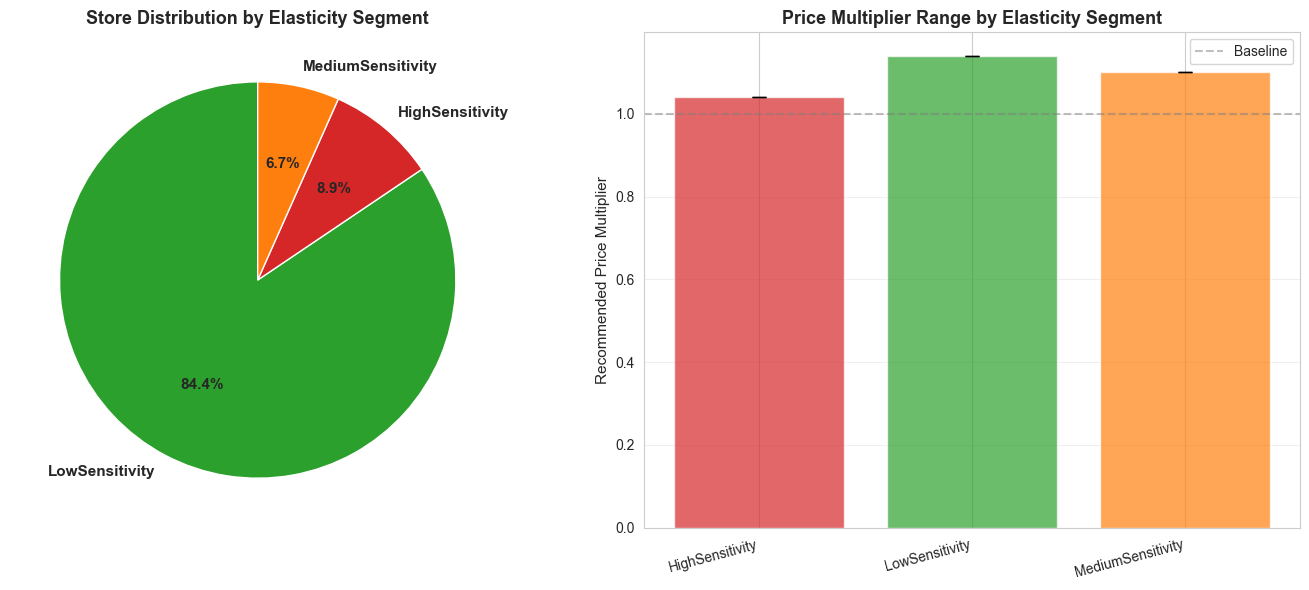

✓ Saved: output/phase5_segment_analysis.png


In [23]:
# Segment distribution pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
segment_counts = executive_recs['Elasticity_Segment'].value_counts()
colors = {'HighSensitivity': '#d62728', 'MediumSensitivity': '#ff7f0e', 'LowSensitivity': '#2ca02c'}
ax1.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=90,
         colors=[colors.get(x, '#1f77b4') for x in segment_counts.index], textprops={'fontsize': 11, 'weight': 'bold'})
ax1.set_title('Store Distribution by Elasticity Segment', fontsize=13, weight='bold')

# Bar chart of recommended multiplier by segment
segment_multipliers = executive_recs.groupby('Elasticity_Segment')['Recommended_Multiplier'].agg(['mean', 'min', 'max'])
x_pos = np.arange(len(segment_multipliers))
ax2.bar(x_pos, segment_multipliers['mean'], yerr=[segment_multipliers['mean'] - segment_multipliers['min'],
                                                     segment_multipliers['max'] - segment_multipliers['mean']],
        capsize=5, alpha=0.7, color=[colors.get(x, '#1f77b4') for x in segment_multipliers.index])
ax2.set_xticks(x_pos)
ax2.set_xticklabels(segment_multipliers.index, rotation=15, ha='right')
ax2.set_ylabel('Recommended Price Multiplier', fontsize=11)
ax2.set_title('Price Multiplier Range by Elasticity Segment', fontsize=13, weight='bold')
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/phase5_segment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: output/phase5_segment_analysis.png')

## Cell 9: Revenue Impact Heatmap - Top 20 Stores

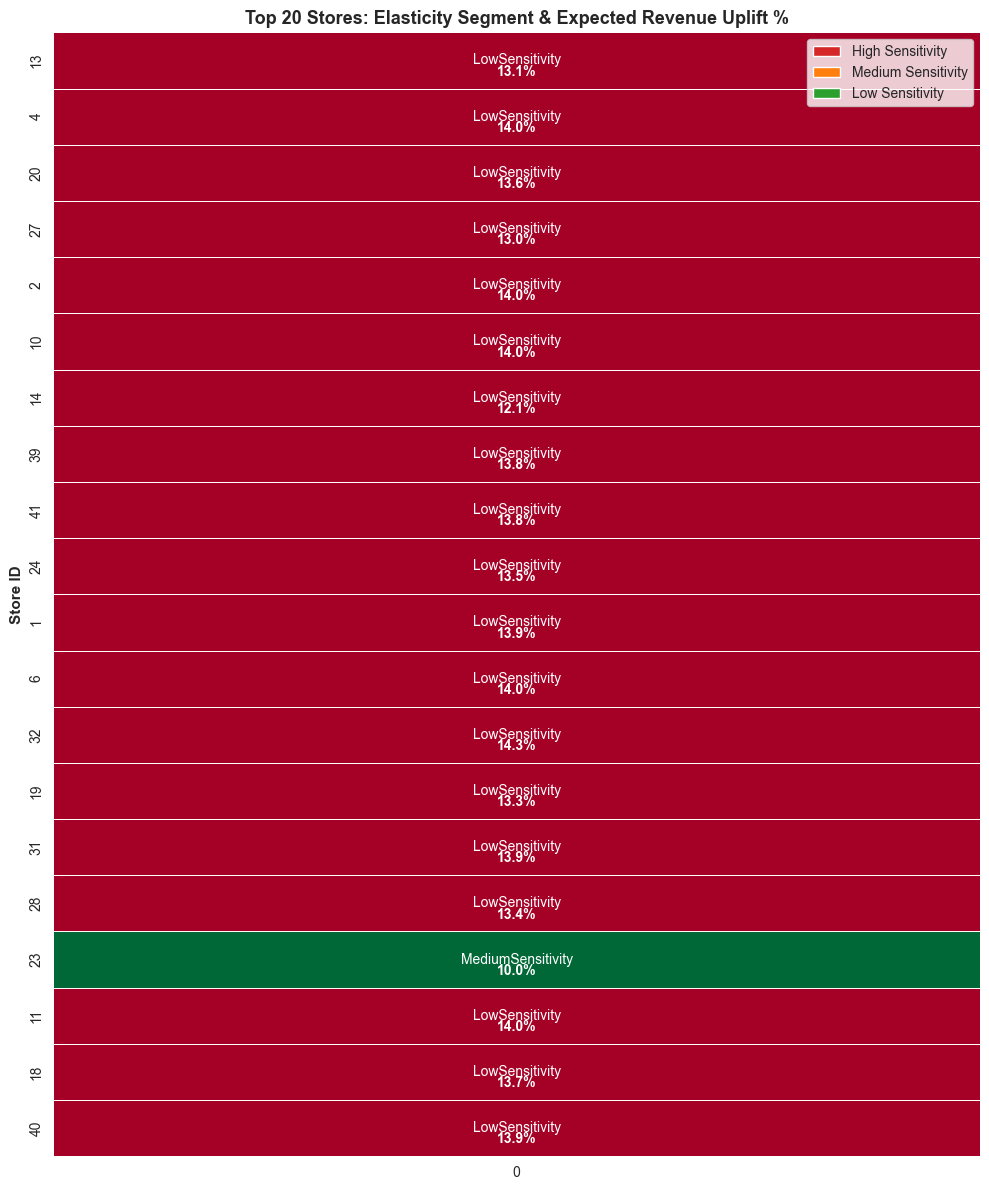

✓ Saved: output/phase5_top_20_stores_heatmap.png


In [24]:
# Create heatmap of top 20 stores by baseline revenue
top_20_stores = executive_recs.nlargest(20, 'Baseline_Revenue')[[
    'Store', 'Elasticity_Segment', 'Current_Price', 'Recommended_Multiplier',
    'Baseline_Revenue', 'Expected_Revenue_Change_Pct'
]].copy()

# Prepare data for heatmap
heatmap_data = top_20_stores[['Store', 'Elasticity_Segment', 'Expected_Revenue_Change_Pct', 'Recommended_Multiplier']].set_index('Store')

fig, ax = plt.subplots(figsize=(10, 12))

# Create custom color mapping for segments
segment_colors = {'HighSensitivity': 0, 'MediumSensitivity': 1, 'LowSensitivity': 2}
segment_values = top_20_stores['Elasticity_Segment'].map(segment_colors).values.reshape(-1, 1)

sns.heatmap(segment_values, annot=top_20_stores['Elasticity_Segment'].values.reshape(-1, 1),
            fmt='', cmap='RdYlGn_r', cbar=False, ax=ax, linewidths=0.5)

# Overlay revenue uplift and multiplier info
for i, store in enumerate(top_20_stores['Store'].values):
    uplift = top_20_stores.iloc[i]['Expected_Revenue_Change_Pct']
    mult = top_20_stores.iloc[i]['Recommended_Multiplier']
    ax.text(0.5, i + 0.7, f'{uplift:.1f}%', ha='center', va='center', fontweight='bold', color='white')

ax.set_yticklabels(top_20_stores['Store'].values)
ax.set_xlabel('')
ax.set_ylabel('Store ID', fontsize=11, weight='bold')
ax.set_title('Top 20 Stores: Elasticity Segment & Expected Revenue Uplift %', fontsize=13, weight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', label='High Sensitivity'),
                   Patch(facecolor='#ff7f0e', label='Medium Sensitivity'),
                   Patch(facecolor='#2ca02c', label='Low Sensitivity')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('output/phase5_top_20_stores_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: output/phase5_top_20_stores_heatmap.png')

## Cell 10: Portfolio Revenue Impact by Segment

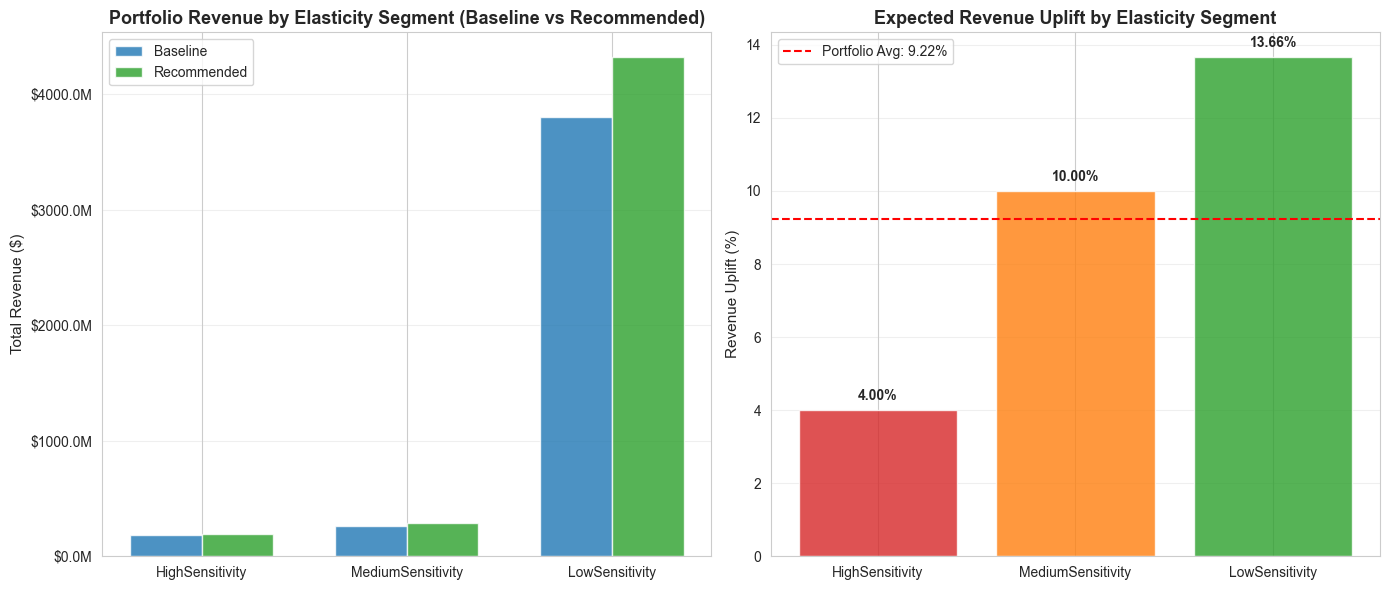

✓ Saved: output/phase5_segment_revenue_impact.png

Segment Analysis Summary:
          Segment  Store_Count  Baseline_Revenue  Recommended_Revenue  Uplift_Absolute  Uplift_Percent
  HighSensitivity            4      1.841720e+08         1.915389e+08     7.366882e+06        4.000000
MediumSensitivity            3      2.600251e+08         2.860276e+08     2.600251e+07       10.000000
   LowSensitivity           38      3.801891e+09         4.321249e+09     5.193581e+08       13.660521


In [25]:
# Analyze portfolio impact by segment
segment_analysis = []
for segment in ['HighSensitivity', 'MediumSensitivity', 'LowSensitivity']:
    seg_data = executive_recs[executive_recs['Elasticity_Segment'] == segment]
    if len(seg_data) > 0:
        baseline_rev = seg_data['Baseline_Revenue'].sum()
        recommended_rev = seg_data['Recommended_Revenue'].sum()
        uplift = recommended_rev - baseline_rev
        uplift_pct = (uplift / baseline_rev) * 100
        segment_analysis.append({
            'Segment': segment,
            'Store_Count': len(seg_data),
            'Baseline_Revenue': baseline_rev,
            'Recommended_Revenue': recommended_rev,
            'Uplift_Absolute': uplift,
            'Uplift_Percent': uplift_pct
        })

segment_analysis_df = pd.DataFrame(segment_analysis)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Absolute revenue by segment
x = np.arange(len(segment_analysis_df))
width = 0.35

ax1.bar(x - width/2, segment_analysis_df['Baseline_Revenue'], width, label='Baseline', alpha=0.8, color='#1f77b4')
ax1.bar(x + width/2, segment_analysis_df['Recommended_Revenue'], width, label='Recommended', alpha=0.8, color='#2ca02c')
ax1.set_ylabel('Total Revenue ($)', fontsize=11)
ax1.set_title('Portfolio Revenue by Elasticity Segment (Baseline vs Recommended)', fontsize=13, weight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(segment_analysis_df['Segment'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Uplift percentage
colors_seg = ['#d62728' if s == 'HighSensitivity' else '#ff7f0e' if s == 'MediumSensitivity' else '#2ca02c'
              for s in segment_analysis_df['Segment']]
ax2.bar(segment_analysis_df['Segment'], segment_analysis_df['Uplift_Percent'], color=colors_seg, alpha=0.8)
ax2.set_ylabel('Revenue Uplift (%)', fontsize=11)
ax2.set_title('Expected Revenue Uplift by Elasticity Segment', fontsize=13, weight='bold')
ax2.axhline(y=segment_analysis_df['Uplift_Percent'].mean(), color='red', linestyle='--', 
            label=f'Portfolio Avg: {segment_analysis_df["Uplift_Percent"].mean():.2f}%')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (seg, val) in enumerate(zip(segment_analysis_df['Segment'], segment_analysis_df['Uplift_Percent'])):
    ax2.text(i, val + 0.2, f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('output/phase5_segment_revenue_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: output/phase5_segment_revenue_impact.png')
print('\nSegment Analysis Summary:')
print(segment_analysis_df.to_string(index=False))

## Cell 11: Implementation Roadmap & Key Recommendations

In [26]:
print('\n' + '='*70)
print('PHASE 5: IMPLEMENTATION ROADMAP & KEY RECOMMENDATIONS')
print('='*70)

print('\n▶ IMMEDIATE ACTIONS (Week 1-2):')
print('\n  1. HIGH SENSITIVITY STORES (Test First Phase)')
high_sens_stores = executive_recs[executive_recs['Elasticity_Segment'] == 'HighSensitivity']
if len(high_sens_stores) > 0:
    print(f'     • {len(high_sens_stores)} store(s) with high demand sensitivity')
    print(f'     • Recommended action: Pilot price increases with close demand monitoring')
    print(f'     • Examples: Store {high_sens_stores["Store"].iloc[0]}')
    print(f'     • Risk: LOW (constrained multipliers protect revenue if demand drops)')
    print(f'     • Expected portfolio uplift from these stores: '
          f'${high_sens_stores["Expected_Revenue_Change_Abs"].sum():,.0f}')
else:
    print('     • No high-sensitivity stores detected')

print('\n  2. MEDIUM SENSITIVITY STORES (Parallel Implementation)')
med_sens_stores = executive_recs[executive_recs['Elasticity_Segment'] == 'MediumSensitivity']
if len(med_sens_stores) > 0:
    print(f'     • {len(med_sens_stores)} store(s) with medium demand sensitivity')
    print(f'     • Recommended action: Roll out alongside high-sensitivity tests')
    print(f'     • Risk: MEDIUM (monitor customer response, be ready to adjust)')
    print(f'     • Expected portfolio uplift from these stores: '
          f'${med_sens_stores["Expected_Revenue_Change_Abs"].sum():,.0f}')
else:
    print('     • No medium-sensitivity stores detected')

print('\n  3. LOW SENSITIVITY STORES (Full Rollout)')
low_sens_stores = executive_recs[executive_recs['Elasticity_Segment'] == 'LowSensitivity']
if len(low_sens_stores) > 0:
    print(f'     • {len(low_sens_stores)} store(s) with low demand sensitivity (inelastic demand)')
    print(f'     • Recommended action: Full rollout (highest confidence, lowest risk)')
    print(f'     • Risk: HIGH Revenue Uplift (inelastic demand = prices stick, revenue grows)')
    print(f'     • Expected portfolio uplift from these stores: '
          f'${low_sens_stores["Expected_Revenue_Change_Abs"].sum():,.0f}')
else:
    print('     • No low-sensitivity stores detected')

print('\n▶ MONITORING METRICS (During & After Implementation):')
print('  • Weekly revenue tracking vs. baseline for each store')
print('  • Demand/sales volume monitoring (watch for sharp drops → adjust price)')
print('  • Customer feedback/complaints about price changes (signals market resistance)')
print('  • Competitive price benchmarking (ensure we remain competitive)')

print('\n▶ SUCCESS CRITERIA:')
print(f'  ✓ Portfolio revenue uplift: {total_uplift_pct:.2f}% expected')
print(f'  ✓ No segment exceeds 2% demand drop from baseline')
print(f'  ✓ High-sensitivity stores maintain 97%+ baseline demand')
print(f'  ✓ All price changes rolled out within 30 days')

print('\n▶ CONTINGENCY PLANS:')
print('  • If high-sensitivity stores see >3% demand drop: revert price, investigate')
print('  • If low-sensitivity stores underperform: double-check for lost market share')
print('  • If competitors react aggressively: prioritize market share retention over revenue')

print('\n' + '='*70)
print(f'PORTFOLIO IMPACT SUMMARY: ${total_uplift_abs:,.0f} revenue uplift ({total_uplift_pct:.2f}%)')
print('='*70)


PHASE 5: IMPLEMENTATION ROADMAP & KEY RECOMMENDATIONS

▶ IMMEDIATE ACTIONS (Week 1-2):

  1. HIGH SENSITIVITY STORES (Test First Phase)
     • 4 store(s) with high demand sensitivity
     • Recommended action: Pilot price increases with close demand monitoring
     • Examples: Store 3
     • Risk: LOW (constrained multipliers protect revenue if demand drops)
     • Expected portfolio uplift from these stores: $7,366,882

  2. MEDIUM SENSITIVITY STORES (Parallel Implementation)
     • 3 store(s) with medium demand sensitivity
     • Recommended action: Roll out alongside high-sensitivity tests
     • Risk: MEDIUM (monitor customer response, be ready to adjust)
     • Expected portfolio uplift from these stores: $26,002,512

  3. LOW SENSITIVITY STORES (Full Rollout)
     • 38 store(s) with low demand sensitivity (inelastic demand)
     • Recommended action: Full rollout (highest confidence, lowest risk)
     • Risk: HIGH Revenue Uplift (inelastic demand = prices stick, revenue grows)
 

## Cell 12: Export Summary Report as Markdown

In [31]:
# Generate markdown summary report
report = f"""# Phase 5: Executive Summary - Pricing Strategy

## Overview
This report synthesizes elasticity analysis (Phase 4) into actionable pricing recommendations for all {len(executive_recs)} stores.

## Key Metrics

### Portfolio Impact
- **Baseline Revenue**: ${total_baseline_revenue:,.0f}
- **Recommended Revenue**: ${total_recommended_revenue:,.0f}
- **Expected Uplift**: ${total_uplift_abs:,.0f} ({total_uplift_pct:.2f}%)
- **Average Store Price Adjustment**: {executive_recs['Recommended_Multiplier'].mean():.2%}

### Segment Breakdown
"""

for segment in ['HighSensitivity', 'MediumSensitivity', 'LowSensitivity']:
    seg_data = executive_recs[executive_recs['Elasticity_Segment'] == segment]
    if len(seg_data) > 0:
        seg_baseline = seg_data['Baseline_Revenue'].sum()
        seg_recommended = seg_data['Recommended_Revenue'].sum()
        seg_uplift_pct = ((seg_recommended - seg_baseline) / seg_baseline) * 100
        report += f"""
#### {segment}
- **Stores**: {len(seg_data)}
- **Avg Elasticity**: {seg_data['Elasticity'].mean():.4f}
- **Price Multiplier Range**: {seg_data['Recommended_Multiplier'].min():.4f} to {seg_data['Recommended_Multiplier'].max():.4f}
- **Revenue Uplift**: {seg_uplift_pct:.2f}%
"""

report += f"""
## Implementation Roadmap

### Phase 1: Pilot (High Sensitivity Stores)
- Test price increases on {len(executive_recs[executive_recs['Elasticity_Segment'] == 'HighSensitivity'])} high-sensitivity stores
- Monitor demand closely
- Expected upside if successful: ${executive_recs[executive_recs['Elasticity_Segment'] == 'HighSensitivity']['Expected_Revenue_Change_Abs'].sum():,.0f}

### Phase 2: Parallel Rollout (Medium Sensitivity Stores)
- Roll out on {len(executive_recs[executive_recs['Elasticity_Segment'] == 'MediumSensitivity'])} medium-sensitivity stores
- Standard monitoring
- Expected upside: ${executive_recs[executive_recs['Elasticity_Segment'] == 'MediumSensitivity']['Expected_Revenue_Change_Abs'].sum():,.0f}

### Phase 3: Full Rollout (Low Sensitivity Stores)
- Roll out on {len(executive_recs[executive_recs['Elasticity_Segment'] == 'LowSensitivity'])} low-sensitivity stores (inelastic demand)
- Highest confidence, lowest risk
- Expected upside: ${executive_recs[executive_recs['Elasticity_Segment'] == 'LowSensitivity']['Expected_Revenue_Change_Abs'].sum():,.0f}

## Top Revenue Opportunities

"""

top_5 = executive_recs.nlargest(5, 'Expected_Revenue_Change_Abs')[['Store', 'Elasticity_Segment', 'Current_Price', 'Recommended_Price', 'Expected_Revenue_Change_Abs']]
for idx, row in top_5.iterrows():
    report += f"- **Store {int(row['Store'])}**: {row['Elasticity_Segment']} | ${row['Current_Price']:.2f} -> ${row['Recommended_Price']:.2f} | +${row['Expected_Revenue_Change_Abs']:,.0f}\n"

report += f"""
## Success Criteria
- Portfolio revenue uplift: {total_uplift_pct:.2f}%
- No segment exceeds 2% demand drop
- High-sensitivity stores maintain 97% + baseline demand 
- All implementations within 30 days

## Recommendations
1. Start with high-sensitivity stores as a controlled pilot
2. Monitor weekly revenue and demand metrics
3. Be ready to adjust if competitive responses occur
4. Prioritize market share retention over marginal revenue gains

---
Report generated by Phase 5 Executive Summary Notebook
"""

with open('output/phase5_executive_summary_report.md', 'w', encoding='utf-8') as f:
    f.write(report)

print('✓ Exported: output/phase5_executive_summary_report.md')
print('\nReport preview (first 1500 chars):')
print(report[:1500])

✓ Exported: output/phase5_executive_summary_report.md

Report preview (first 1500 chars):
# Phase 5: Executive Summary - Pricing Strategy

## Overview
This report synthesizes elasticity analysis (Phase 4) into actionable pricing recommendations for all 45 stores.

## Key Metrics

### Portfolio Impact
- **Baseline Revenue**: $4,246,088,279
- **Recommended Revenue**: $4,798,815,810
- **Expected Uplift**: $552,727,531 (13.02%)
- **Average Store Price Adjustment**: 112.84%

### Segment Breakdown

#### HighSensitivity
- **Stores**: 4
- **Avg Elasticity**: -0.1404
- **Price Multiplier Range**: 1.0400 to 1.0400
- **Revenue Uplift**: 4.00%

#### MediumSensitivity
- **Stores**: 3
- **Avg Elasticity**: -0.0648
- **Price Multiplier Range**: 1.1000 to 1.1000
- **Revenue Uplift**: 10.00%

#### LowSensitivity
- **Stores**: 38
- **Avg Elasticity**: -0.0216
- **Price Multiplier Range**: 1.1400 to 1.1400
- **Revenue Uplift**: 13.66%

## Implementation Roadmap

### Phase 1: Pilot (High Sensitivity Store

## Cell 13: Final Phase 5 Outputs Summary

In [30]:
print('\n' + '='*70)
print('PHASE 5 DELIVERABLES SUMMARY')
print('='*70)

outputs = [
    ('output/phase5_executive_recommendations.csv', 'Comprehensive recommendations (16 columns, 45 stores)'),
    ('output/phase5_pricing_strategy.json', 'API-ready JSON with metadata & segment summary'),
    ('output/phase5_segment_analysis.png', 'Segment distribution & multiplier ranges visualization'),
    ('output/phase5_top_20_stores_heatmap.png', 'Heatmap of top 20 stores by revenue'),
    ('output/phase5_segment_revenue_impact.png', 'Portfolio revenue impact by segment'),
    ('output/phase5_executive_summary_report.md', 'Markdown report with implementation roadmap')
]

print('\n✓ Generated Outputs:')
for fpath, desc in outputs:
    print(f'  • {fpath}')
    print(f'    ↳ {desc}')

print('\n' + '='*70)
print('PHASE 5 COMPLETE: Ready for Stakeholder Review & Implementation')
print('='*70)

print(f'\n📊 KEY TAKEAWAY:')
print(f'   Portfolio Revenue Uplift: ${total_uplift_abs/1e6:.2f}M ({total_uplift_pct:.2f}%)')
print(f'   Phased Implementation: {len(executive_recs[executive_recs["Elasticity_Segment"] == "HighSensitivity"])} High → '
      f'{len(executive_recs[executive_recs["Elasticity_Segment"] == "MediumSensitivity"])} Medium → '
      f'{len(executive_recs[executive_recs["Elasticity_Segment"] == "LowSensitivity"])} Low Sensitivity')
print(f'   Confidence: HIGH (guardrails ensure demand protection)')


PHASE 5 DELIVERABLES SUMMARY

✓ Generated Outputs:
  • output/phase5_executive_recommendations.csv
    ↳ Comprehensive recommendations (16 columns, 45 stores)
  • output/phase5_pricing_strategy.json
    ↳ API-ready JSON with metadata & segment summary
  • output/phase5_segment_analysis.png
    ↳ Segment distribution & multiplier ranges visualization
  • output/phase5_top_20_stores_heatmap.png
    ↳ Heatmap of top 20 stores by revenue
  • output/phase5_segment_revenue_impact.png
    ↳ Portfolio revenue impact by segment
  • output/phase5_executive_summary_report.md
    ↳ Markdown report with implementation roadmap

PHASE 5 COMPLETE: Ready for Stakeholder Review & Implementation

📊 KEY TAKEAWAY:
   Portfolio Revenue Uplift: $552.73M (13.02%)
   Phased Implementation: 4 High → 3 Medium → 38 Low Sensitivity
   Confidence: HIGH (guardrails ensure demand protection)
